In [4]:
import numpy as np
import matplotlib.pyplot as plt

Problem 1

Pokaż, że suma dwóch (lub ogólniej – większej liczby) zmiennych normalnych
nie musi mieć rozkładu normalnego.

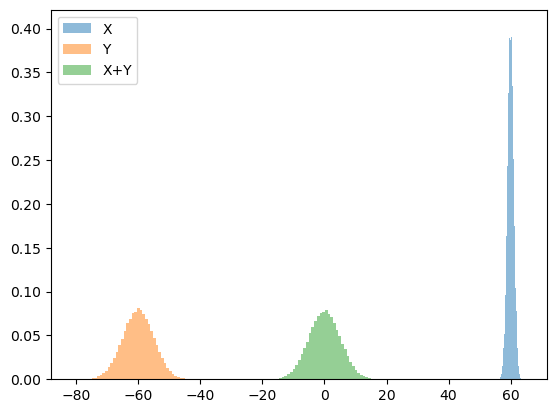

In [ ]:
X = np.random.normal(loc=60, scale=1, size=100000)
Y = np.random.normal(loc=-60, scale=5, size=100000) 
XandY = X + Y

plt.hist(X, bins=50, density=True, alpha=0.5, label='X')
plt.hist(Y, bins=50, density=True, alpha=0.5, label='Y')
plt.hist(XandY, bins=50, density=True, alpha=0.5, label='X+Y')
plt.legend()
plt.show()

Problem 2

(Symulacja rozkładu α-stabilnego). Przygotuj program, który symuluje próbkę
o symetrycznym rozkładzie α-stabilnym S(α, β, γ, δ; 0) oraz S(α, β, γ, δ; 1) zdefiniowanych w
definicjach Def. 1.7 oraz Def. 1.8 w Rozdziale 1.

In [6]:
def genZ(alpha, beta, theta, W):
  if alpha == 1: 
    Z = (2/np.pi) * (((np.pi/2)+beta*theta)*np.tan(theta) - beta*np.log((np.pi/2)*W*np.cos(theta)/((np.pi/2)+beta*theta)))
  else:
    theta0 = np.arctan(beta*np.tan(np.pi*alpha/2))/alpha
    Z = (np.sin(alpha*(theta0 + theta))/((np.cos(alpha*theta0)*np.cos(theta))**(1/alpha))) * ((np.cos(alpha*theta0 + (alpha - 1)*theta)/W)**((1-alpha)/alpha))
  return Z

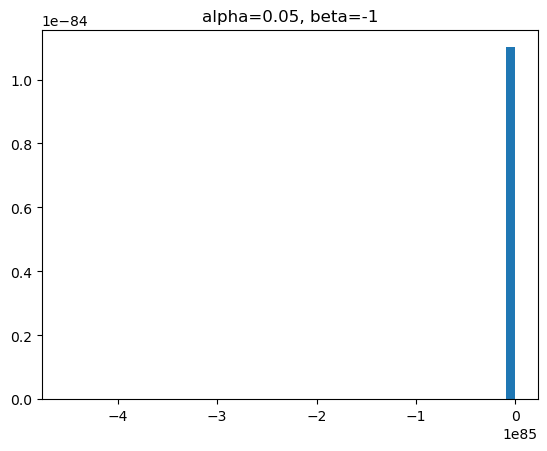

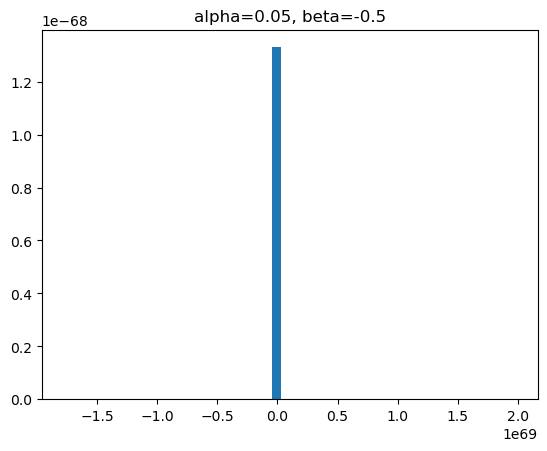

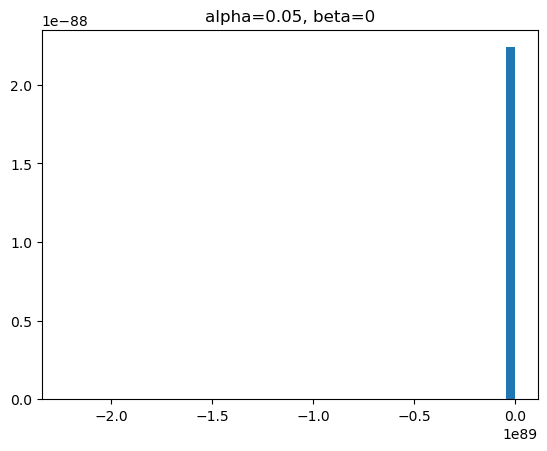

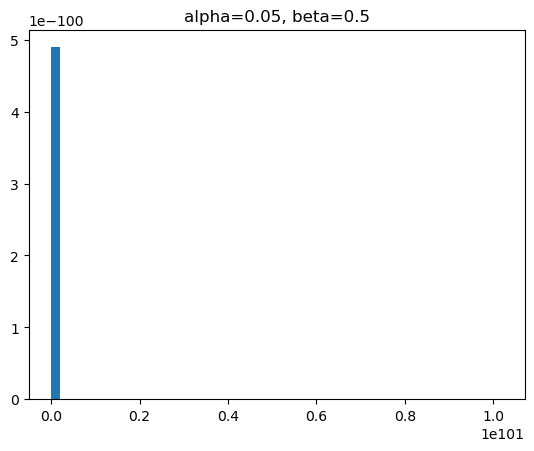

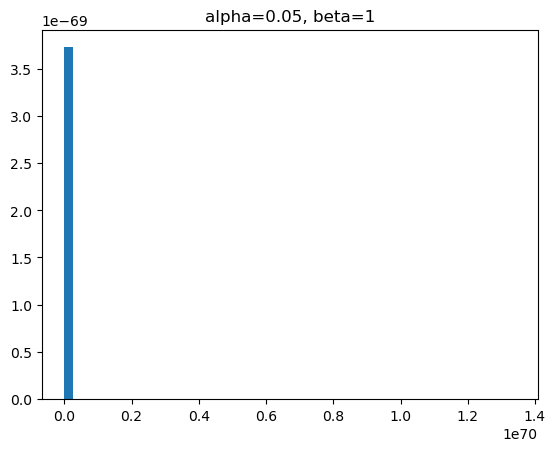

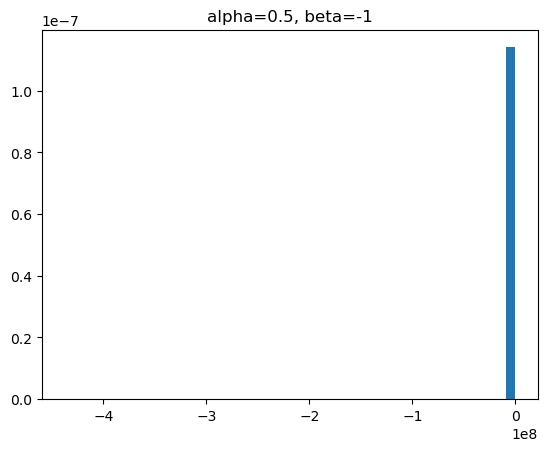

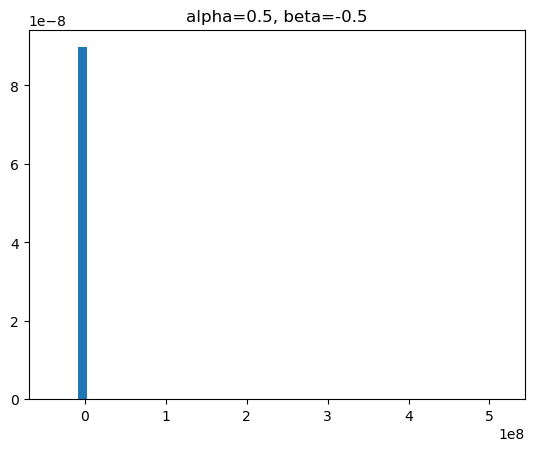

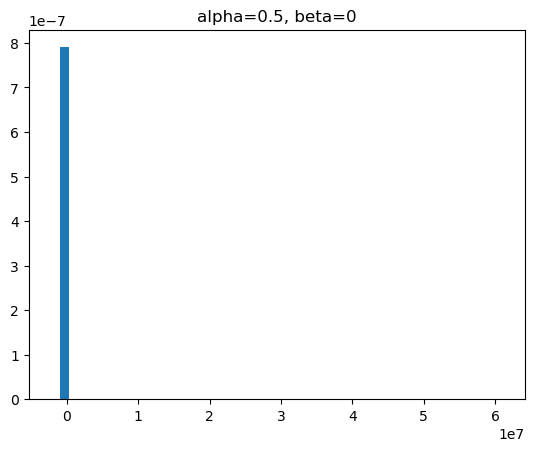

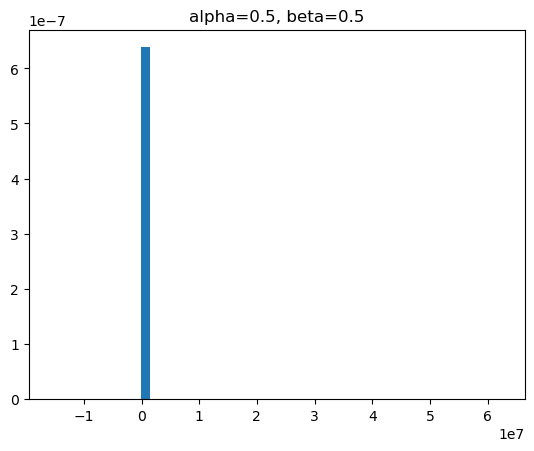

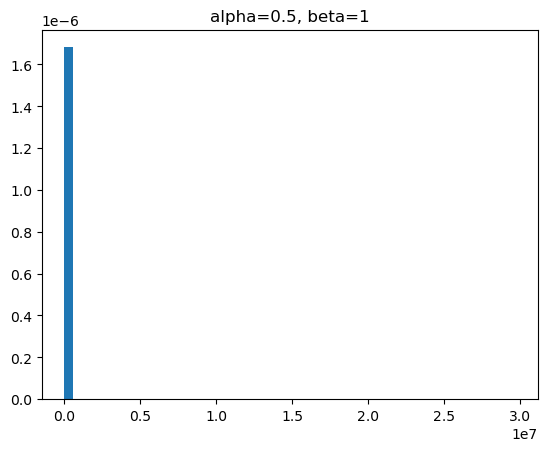

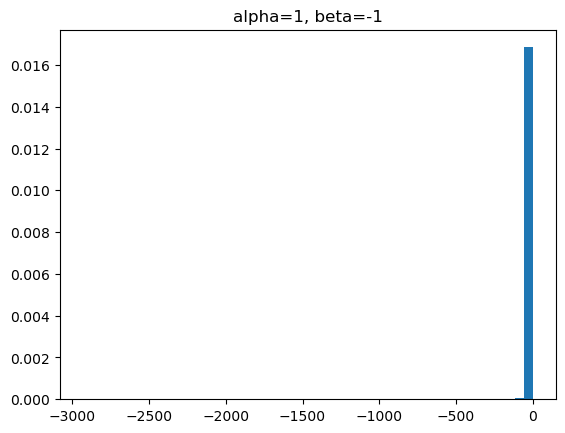

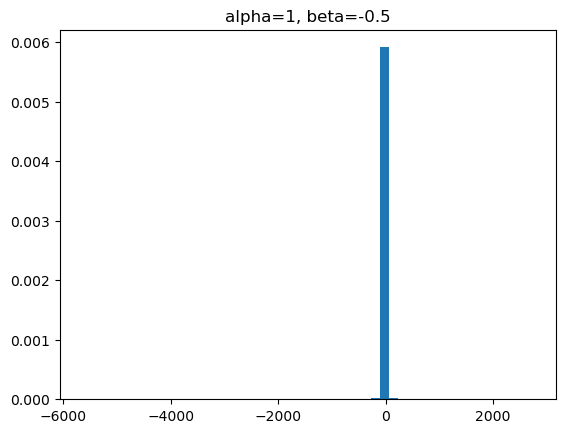

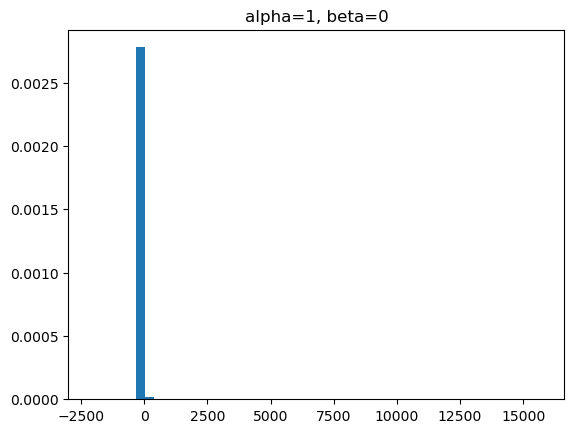

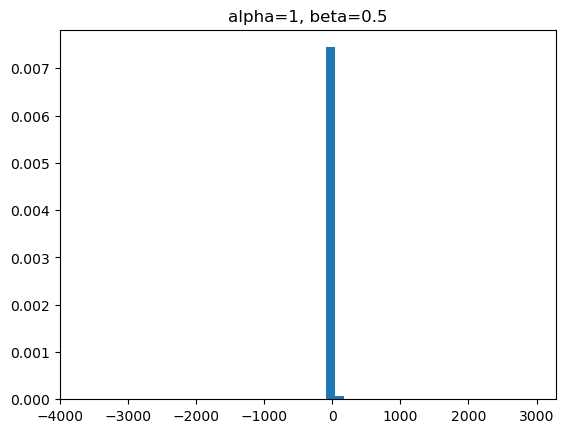

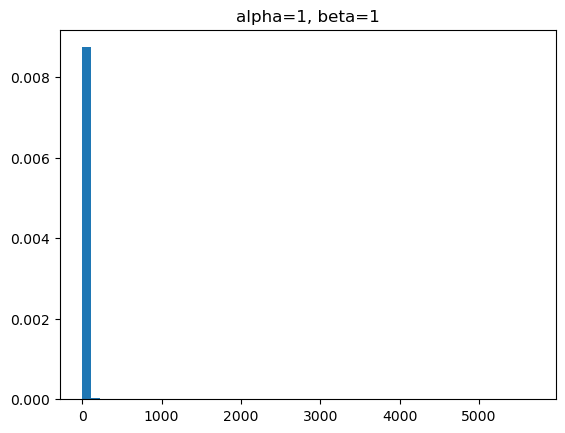

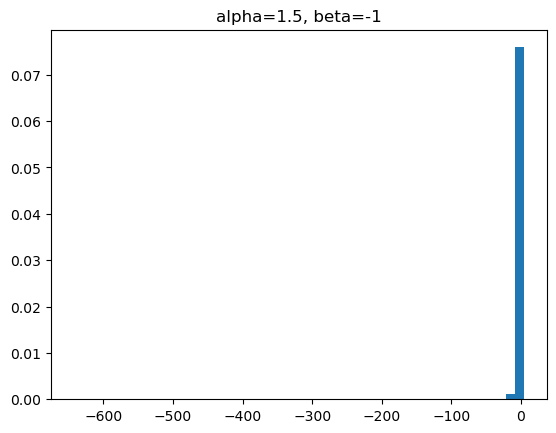

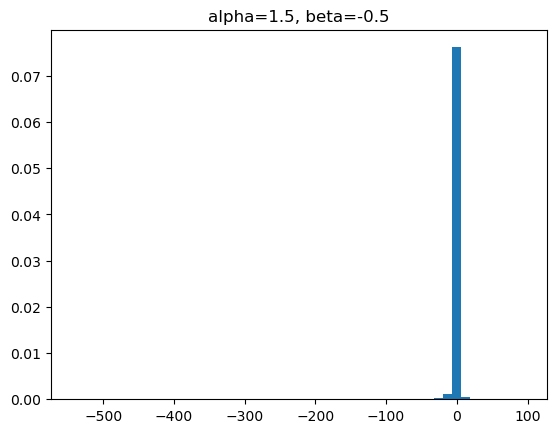

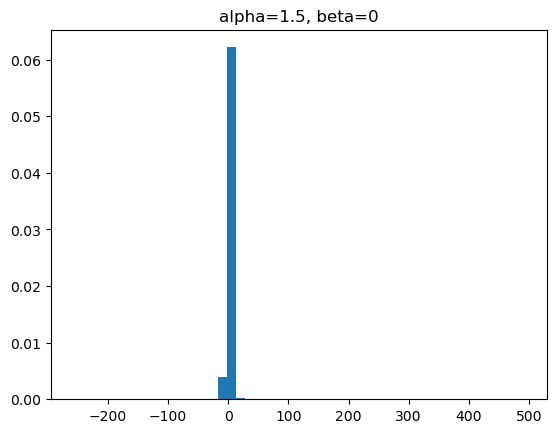

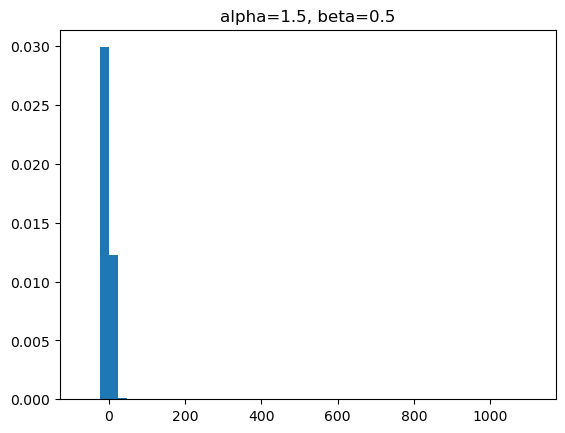

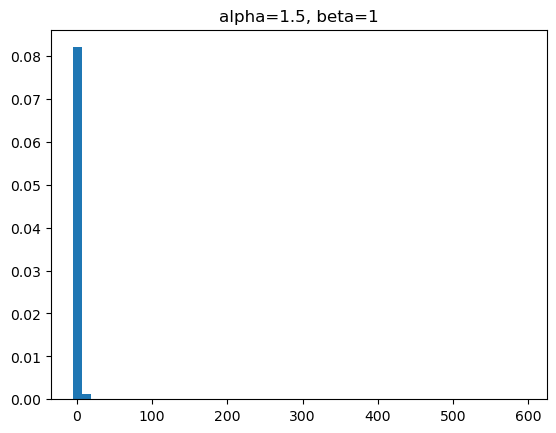

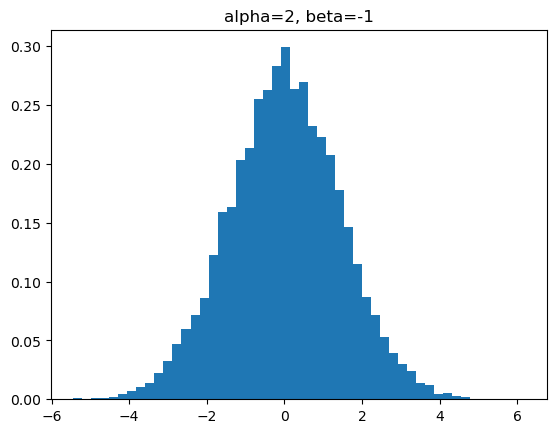

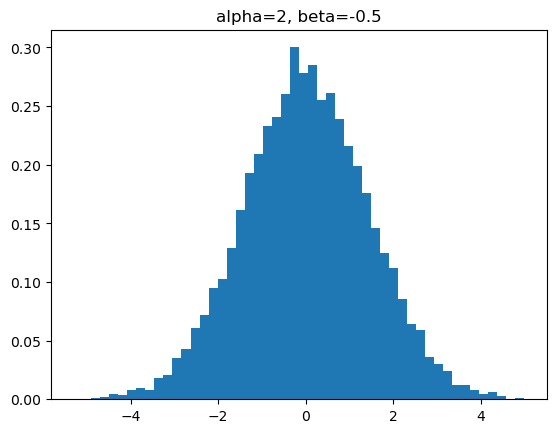

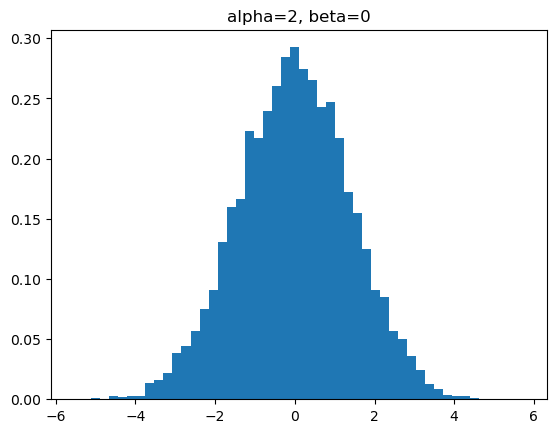

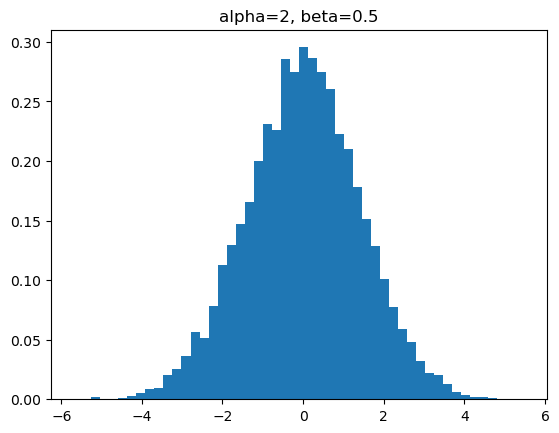

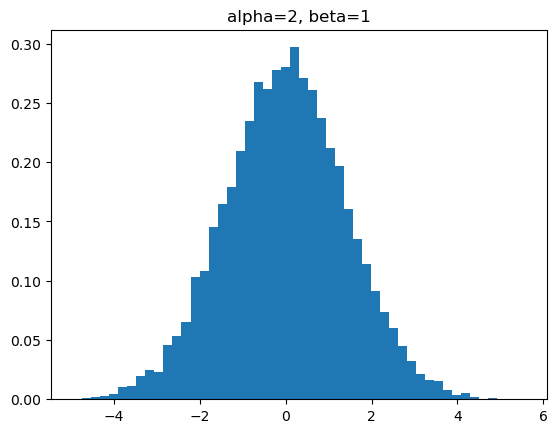

In [ ]:
Ztable = []
alphaBetaZ = []

for alpha in [0.05, 0.5, 1, 1.5, 2]:
  for beta in [-1, -0.5, 0, 0.5, 1]:
    for i in range(10000):
      theta = np.random.uniform(-np.pi/2, np.pi/2)
      W = np.random.exponential(1)
      Z = genZ(alpha, beta, theta, W)
      Ztable.append(Z)
    alphaBetaZ.append((alpha, beta, Ztable))
    Ztable = []
  
for alpha, beta, Z in alphaBetaZ:
  plt.hist(Z, bins=50, density=True)
  plt.title(f'alpha={alpha}, beta={beta}')
  plt.show()

In [8]:
def S(alpha, beta, gamma, delta, zeroOne, Z):
  if zeroOne == 0:
    if alpha == 1:
      X = gamma*Z + delta
    else:
      X = gamma*(Z-beta*np.tan(np.pi/2*(alpha))) +delta
  else:
    if alpha == 1:
      X = gamma*Z + (delta + beta*(2/np.pi)*gamma*np.log(gamma))
    else:
      X = gamma*Z + delta
  return X

Problem 3

(Funkcja charakterystyczna symetrycznych rozkładów α-stabilnych). Porów-
naj empiryczną funkcję charakterystyczną obliczoną dla próbek z symetrycznego rozkładu α-
stabilnego (β = 0, δ = 0) z jej dokładną postacią
α
φX (t) = e−c|t| ,
t∈R
dla pewnego c ≥ 0 (jak parametr c jest powiązany z pozostałymi parametrami rozkładu α-
stabilnego?).
Jak można w prosty sposób wyjaśnić, że dla symetrycznego rozkładu α-stabilnego funkcja
charakterystyczna nie posiada części urojonej?

Ss mean: 36496.07579531915
Zz mean: 36496.07579531915


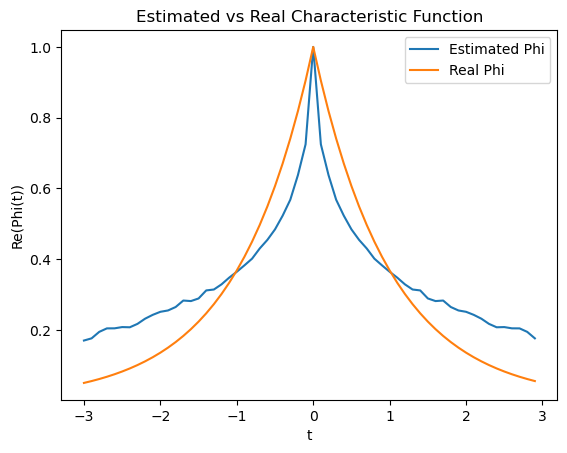

In [ ]:
def estPhi(t,X):
  N = len(X)
  phi = 0
  for x in X:
    phi += np.exp(1j*t*x) 
  return phi/N

def realPhi(t,c,alpha):
  return np.exp(-c*np.abs(t)**alpha)
 

alpha = 0.5
beta = 0.0
gamma = 1
delta = 0
Ss = np.array([])
Zz = np.array([])

for i in range(10000):

  theta = np.random.uniform(-np.pi/2, np.pi/2)
  W = np.random.exponential(1)
  Z = genZ(alpha, beta, theta, W)
  S_value = S(alpha, beta, gamma, delta, 1, Z)
  Ss = np.append(Ss, S_value)
  Zz = np.append(Zz, Z)

print("Ss mean:", np.mean(Ss))
print("Zz mean:", np.mean(Zz))

phis = []
for t in np.arange(-3.0, 3.0, 0.1):
  ePhi = estPhi(t, Ss)
  rPhi = realPhi(t, 1, 1)
  phis.append((t, ePhi, rPhi))


#Y axis - real phi, X axis - estimated phi
plt.plot([t for t, ePhi, rPhi in phis], [np.real(ePhi) for t, ePhi, rPhi in phis], label='Estimated Phi')
plt.plot([t for t, ePhi, rPhi in phis], [np.real(rPhi) for t, ePhi, rPhi in phis], label='Real Phi')
plt.title('Estimated vs Real Characteristic Function')
plt.xlabel('t')
plt.ylabel('Re(Phi(t))')
plt.legend()
plt.show()

#za 2 tyg kart. opisz znaczenie param w rozkladnie alpha stabilnym, beta, gamma, delta, zeroOne

Problem 4

(Porównanie gęstości dla znanych przypadków). Dla przypadków:
1. rozkład normalny,
2. rozkład Cauchy’ego,
3. rozkład Lévy’ego,
znajdź odpowiednie parametry rozkładu α-stabilnego. Następnie porównaj estymowane gęsto-
ści (oraz, jeśli to możliwe, dystrybuanty) z ich analitycznymi odpowiednikami przedstawio-
nymi w uwagach 1 − 3.

Problem 5

(Ogon dystrybuanty i gęstości). Korzystając z symulacji Monte Carlo pokaż,
że dla X ∼ S(α, β, γ, δ; 0) z 0 < α < 2, −1 < β ≤ 1 zachodzi następujące zachowanie dla
t → ∞:
• P(X > x) ∼ γ α cα (1 + β)t−α ,
• fX (t) ∼ αγ α cα (1 + β)t−(α+1) ,
oraz dla −1 ≤ β < 1, gdy −t → −∞:
• P(X < −t) ∼ γ α cα (1 − β)t−α ,
• fX (−t) ∼ αγ α cα (1 − β)t−(α+1) .
W obu przypadkach parametr
 απ  Γ(α)
.
cα = sin
2
π

# LISTA 2

In [45]:
import scipy.stats as stats
import math

Problem 1:
P(X > t) ~t->inf ~ a_{alhpa,gamma,beta}t^-alhpa

Idea: Rozwazyc ln P(X>t) ~ ln a_{a,g,b}-alpha*ln t
i zrobic reg. lin. ln P(X > t) =y_k = c_0 + c_1*x_k + eps, gdzie x_k = ln t_k,
c_0 = ln a_{a,g,b}, c_1 = -alpha

Zacząć od narysowania:
OY = ln P(X>t) = ln (1-F(t))
OX = ln t

linia prosta y = c_0 + c_1 x''

interesują nas duże t; t_k = 10% najw; ecdf - empirical cumulative dist. fun.

przykladowe x ~ S(a=1.2,gamma=1,beta=0,delta=0)

ecdf = #{X_i:X_i<=t}/N

t = [X_{1:N},...,X_{N:N}]

lnt: [       nan        nan        nan ... 6.19988216 7.26983079 7.45935649]


/tmp/ipykernel_410952/4066639499.py:20: RuntimeWarning: invalid value encountered in log
  lnt = np.log(t)
/tmp/ipykernel_410952/4066639499.py:21: RuntimeWarning: divide by zero encountered in log
  lnfdce = np.log(1 - fdce.cdf.probabilities)


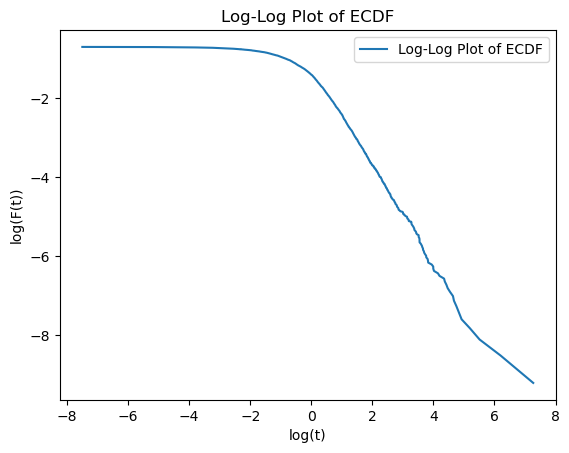

top10percentlnt: [0.89055788 0.89148423 0.89236874 0.89716884 0.8988219  0.90034395
 0.90084973 0.90111182 0.90147188 0.90274265 0.90450135 0.90605654
 0.90630845 0.90745592 0.90827205 0.90840803 0.90936735 0.91229328
 0.91563543 0.91625732 0.91675752 0.9191428  0.9195587  0.92102068
 0.92152708 0.92158708 0.92555395 0.92610588 0.92626552 0.9267233
 0.92681773 0.92710146 0.92740485 0.9279481  0.92924527 0.92937741
 0.92990556 0.93154497 0.93242822 0.93369264 0.93451185 0.93488837
 0.93543414 0.93595769 0.93596233 0.93617515 0.93709095 0.93713355
 0.93724661 0.93826046 0.94022411 0.94038947 0.94087978 0.94131043
 0.9417569  0.94377707 0.94630541 0.94922892 0.94929247 0.94956487
 0.94963965 0.950283   0.95080164 0.95169576 0.95292483 0.95292729
 0.95365925 0.95412549 0.95642208 0.95721358 0.95769591 0.95824658
 0.9587225  0.9594429  0.96085495 0.96160347 0.96315579 0.96348342
 0.96351228 0.96563993 0.96830793 0.97116492 0.9718356  0.97237622
 0.97272997 0.97442572 0.9764427  0.97767498 0

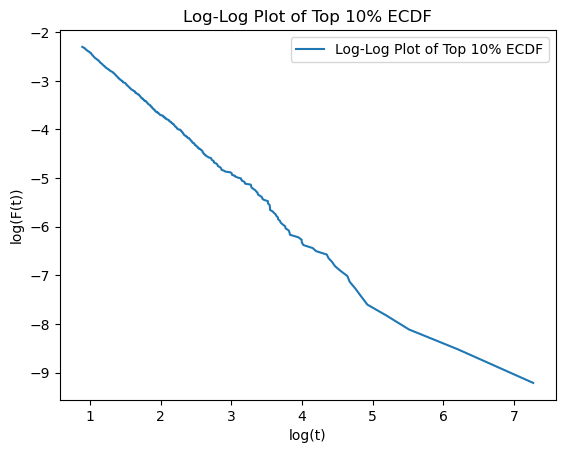

In [35]:
alpha = 1.2
beta = 0.0
gamma = 1
delta = 0

t = np.array([])
for i in range(10000):
  theta = np.random.uniform(-np.pi/2, np.pi/2)
  W = np.random.exponential(1)

  Z = genZ(alpha, beta, theta, W)
  x = S(alpha, beta, gamma, delta, 0, Z)
  t = np.append(t, x)

t = np.sort(t)

fdce = stats.ecdf(t)


lnt = np.log(t)
lnfdce = np.log(1 - fdce.cdf.probabilities)

print("lnt:", lnt)

plt.plot(lnt, lnfdce, label='Log-Log Plot of ECDF')
plt.title('Log-Log Plot of ECDF')
plt.xlabel('log(t)')
plt.ylabel('log(F(t))')
plt.legend()
plt.show()

len_t = len(t)
top10percentlnt = lnt[int(0.9*len_t):]
top10percentlnfdce = lnfdce[int(0.9*len_t):]

print("top10percentlnt:", top10percentlnt)

plt.plot(top10percentlnt, top10percentlnfdce, label='Log-Log Plot of Top 10% ECDF')
plt.title('Log-Log Plot of Top 10% ECDF')
plt.xlabel('log(t)')
plt.ylabel('log(F(t))')
plt.legend()
plt.show()

c_0: -1
c_1: -1.2


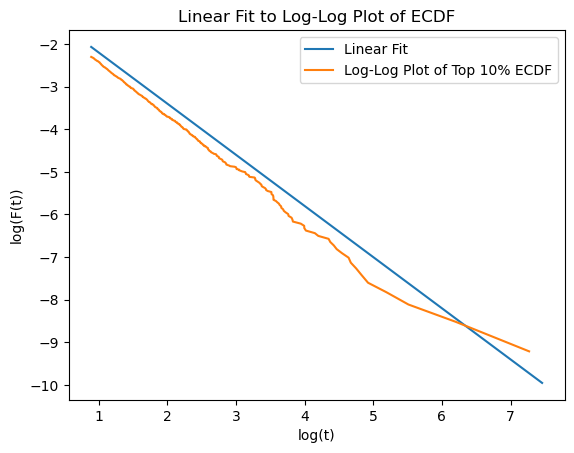

In [ ]:
y = np.array([])
# c_0 = top10percentlnfdce + alpha * top10percentlnt
# c_0 = 0
c_0 = np.sin(alpha*np.pi/2) * math.gamma(alpha)/2
# c_0 = -1
c_1 = -alpha

print("c_0:", c_0)
print("c_1:", c_1)

for i in range(9000, 10000):
  x_i = top10percentlnt[i-9000]
  y_i = c_0 + c_1 * x_i
  y = np.append(y, y_i)

plt.plot(top10percentlnt, y, label='Linear Fit')
plt.plot(top10percentlnt, top10percentlnfdce, label='Log-Log Plot of Top 10% ECDF')
plt.title('Linear Fit to Log-Log Plot of ECDF')
plt.xlabel('log(t)')
plt.ylabel('log(F(t))')
plt.legend()
plt.show()

Problem 2: estymacja funkcji charakterystycznej

X ~ S_alpaha S to phi_x(t) = e^{-gamma^alpha |t|^alpha}
Stąd ln phi_x(t) = gamma^alhpa *|t|^alpha
y_k = ln |ln (est_phi_x(t_k))| = ln(gamma^alpha) + alpha ln|t_k|

x_k = ln|t_k|

c_0: 0.43661518275890926
c_1: -1.2


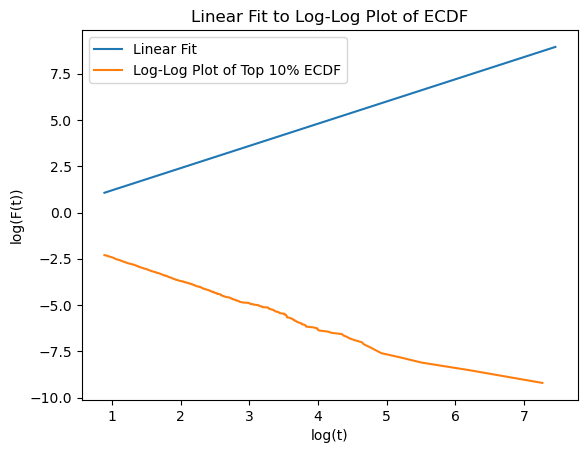

In [52]:
y = np.array([])
# c_0 = top10percentlnfdce + alpha * top10percentlnt
# c_0 = 0
c_0 = np.sin(alpha*np.pi/2) * math.gamma(alpha)/2
# c_0 = -1
c_1 = -alpha

print("c_0:", c_0)
print("c_1:", c_1)

for i in range(9000, 10000):
  x_i = top10percentlnt[i-9000]
  y_i = np.log(gamma**alpha) + alpha * x_i
  y = np.append(y, y_i)

plt.plot(top10percentlnt, y, label='Linear Fit')
plt.plot(top10percentlnt, top10percentlnfdce, label='Log-Log Plot of Top 10% ECDF')
plt.title('Linear Fit to Log-Log Plot of ECDF')
plt.xlabel('log(t)')
plt.ylabel('log(F(t))')
plt.legend()
plt.show()

In [ ]:
estPhi